# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

In [1]:
# imports
import pickle
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import warnings
from toeplitzlda.classification import ToeplitzLDA

# utils functions
from utils.preprocessing import load_session_chached, merge_sessions
from utils.online_simulation import online_simulation
from utils.feature_extraction import load_features_chached
from utils.run_patient import run_patient_online_sessions

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



In [2]:
import line_profiler
%load_ext line_profiler

def my_function(x):
    e = 0
    for i in range(x):
        e+=i

# Example:
%lprun -f my_function my_function(500)

Timer unit: 1e-07 s

Total time: 0.0003431 s
File: C:\Users\Soz\AppData\Local\Temp\ipykernel_45256\559752206.py
Function: my_function at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           def my_function(x):
     5         1          7.0      7.0      0.2      e = 0
     6       501       1731.0      3.5     50.5      for i in range(x):
     7       500       1693.0      3.4     49.3          e+=i

### Test own function

In [ ]:

# features_online = load_features_chached(r"B:\_anonymized_data_P01a_P1_S4_anonymized.pkl")
# # for i in range(3,18):
# #     features = load_features_chached(f"B:\_anonymized_data_P01a_P1_S{i}_anonymized.pkl")

# #for i in range(3,14):
# #    features = load_features_chached(f"B:\_anonymized_data_P02a_P1_S{i}_anonymized.pkl")

# features_train = load_features_chached(r"B:\_anonymized_data_P01a_P1_S3_anonymized.pkl")

# from pathlib import Path
# import re

# def get_help_path_from_pickle_path(pickle_path):
#     """
#     Convert a flattened pickle filename like:
#         B:\_anonymized_data_P01a_P1_S1_anonymized.pkl
#     to the original folder-style path like:
#         B:\anonymized_data\P01a\P1_S1\anonymized
#     """
#     path = Path(pickle_path)
#     fname = path.name

#     match = re.match(r"_anonymized_data_(P\d+a)_(P\d+_S\d+)_anonymized\.pkl", fname)
#     if not match:
#         raise ValueError(f"Could not parse patient/session info from: {fname}")

#     part1 = match.group(1)  # e.g. P01a
#     part2 = match.group(2)  # e.g. P1_S1

#     help_path = path.parent / "anonymized_data" / part1 / part2 / "anonymized"
#     return str(help_path)
# from pathlib import Path
# import re

# import os

# def parse_pickle_path(pickle_path):
#     # Extract the full filename without directory
#     filename = os.path.basename(pickle_path)
    
#     # Regex to extract patient/session info
#     match = re.match(r'_anonymized_data_(P\d{2}a)_P(\d+)_S(\d+)_anonymized(.*)\.pkl', filename)
#     if not match:
#         raise ValueError(f"Invalid filename format: {filename}")
    
#     project, patient, session, suffix = match.groups()

#     # Construct help_path
#     help_path = os.path.join(
#         "B:/", "anonymized_data", project, f"P{patient}_S{session}", "anonymized"
#     )

#     # Extract optional selection and discard_channels from suffix
#     selection = None
#     discard_channels = False

#     if "_dc" in suffix:
#         discard_channels = True
#         suffix = suffix.replace("_dc", "")  # Remove _dc so it doesn't pollute selection

#     # Now match selection without _dc
#     sel_match = re.search(r'(6D_\w+)', suffix)
#     if sel_match:
#         selection = sel_match.group(1)

#     return help_path, selection, discard_channels

# import glob
# import os
# from utils.feature_extraction import load_or_extract_markers

# # Define the folder containing the data
# data_dir = r"B:\\"  # Ensure it ends with a backslash or double backslash

# # Use glob to find all .pkl files that match your pattern
# file_pattern = os.path.join(data_dir, "_anonymized_data*.pkl")
# all_pickle_files = glob.glob(file_pattern)

# print(f"Found {len(all_pickle_files)} .pkl files.")

# # Loop through all files and run your function
# for pickle_path in all_pickle_files:
#     print(f"\nProcessing pickle path: {pickle_path}")
#     #"B:\anonymized_data\P01a\P1_S1\anonymized"
#     help_path, selection, discard_channels = parse_pickle_path(pickle_path=pickle_path)
#     print("help_path:",help_path)  # B:\anonymized_data\P01a\P1_S1\anonymized
#     print("selection:",selection)  # 6D_long_350
#     print("dc:",discard_channels)  # True
#     online_trials = load_session_chached((help_path),selection=selection, discard_channels=discard_channels).get('trials')
#     try:
#         markers_info = load_or_extract_markers(pickle_path, online_trials)
#     except Exception as e:
#         print(f"Failed to process {pickle_path}: {e}")





In [ ]:
features_s1 =load_features_chached(r"B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl")
print(features_s1.keys())

features_s2 =load_features_chached(r"B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl")
print(features_s2.keys())

features_merged = merge_features(features_s1, features_s2)


In [ ]:
### Session 3 --------------------------------------------------------
#Calibration data: sessions 1 and 2 (only runs with same condition as S3)
patient_string = "01"
patient = 1
calibration_selection ="6D_long_350"
calibration_selection_dc =  "6D_long_350_dc"

data_path_s1 = f"B:/anonymized_data/P{patient_string}a/P{patient}_S1/anonymized"
data_path_s2 = f"B:/anonymized_data/P{patient_string}a/P{patient}_S2/anonymized"
data_s1 = load_session_chached(data_path_s1, selection = calibration_selection, discard_channels=True)
data_s2 = load_session_chached(data_path_s2, selection = calibration_selection, discard_channels=True)
data_train = merge_sessions(data_s1, data_s2)
features_s1 = load_features_chached(f"B:_anonymized_data_P{patient_string}a_P{patient}_S1_anonymized{calibration_selection_dc}.pkl")
#print("HIIIIIIIIIIIIIII",features_s1)
features_s2 = load_features_chached(f"B:_anonymized_data_P{patient_string}a_P{patient}_S2_anonymized{calibration_selection_dc}.pkl")
features_train = merge_features(features_s1, features_s2)


if patient == 8:
    data_s3 = load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S3/anonymized")
    data_train = merge_sessions(data_train, data_s3)
    features_s3 = load_features_chached(fr"B:_anonymized_data_P{patient_string}a_P{patient}_S3_anonymized{calibration_selection_dc}.pkl")
    features_train = merge_features(features_train, features_s3)

    data_test = load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S4/anonymized")
    features_test = load_features_chached(fr"B:_anonymized_data_P{patient_string}a_P{patient}_S4_anonymized.pkl")

else:
    data_test = load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S3/anonymized")
    features_test = load_features_chached(fr"B:_anonymized_data_P{patient_string}a_P{patient}_S3_anonymized.pkl")
plot_title_text = f"patient {patient} session 3"

performance_p1_s3_new = online_simulation(data_train, data_test, features_train, features_test, log_process="helloooo.log")

In [ ]:
from utils.db import patients_db

print(patients_db)
for id in patients_db:
    if id==8:
        info = patients_db.get(id)
        patient = info.get('patient_nr')
        last_session = info.get('last_session')
        calibration_selection = info.get('selection')

        print("patient: ", patient)
        print("last session", last_session)
        print("calibration_selection", calibration_selection)

        performances = run_patient_online_sessions(patient, last_session, calibration_selection)
        with open(f"p{patient}_performances_v1.pkl", 'wb') as f: 
            pickle.dump(performances, f)

### other tests

Loading file:  B:_anonymized_data_P01a_P1_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P01a_P1_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P01a_P1_S3_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S3_anonymized.pkl
All calibration trials:  30
That is 2700 epochs

trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84

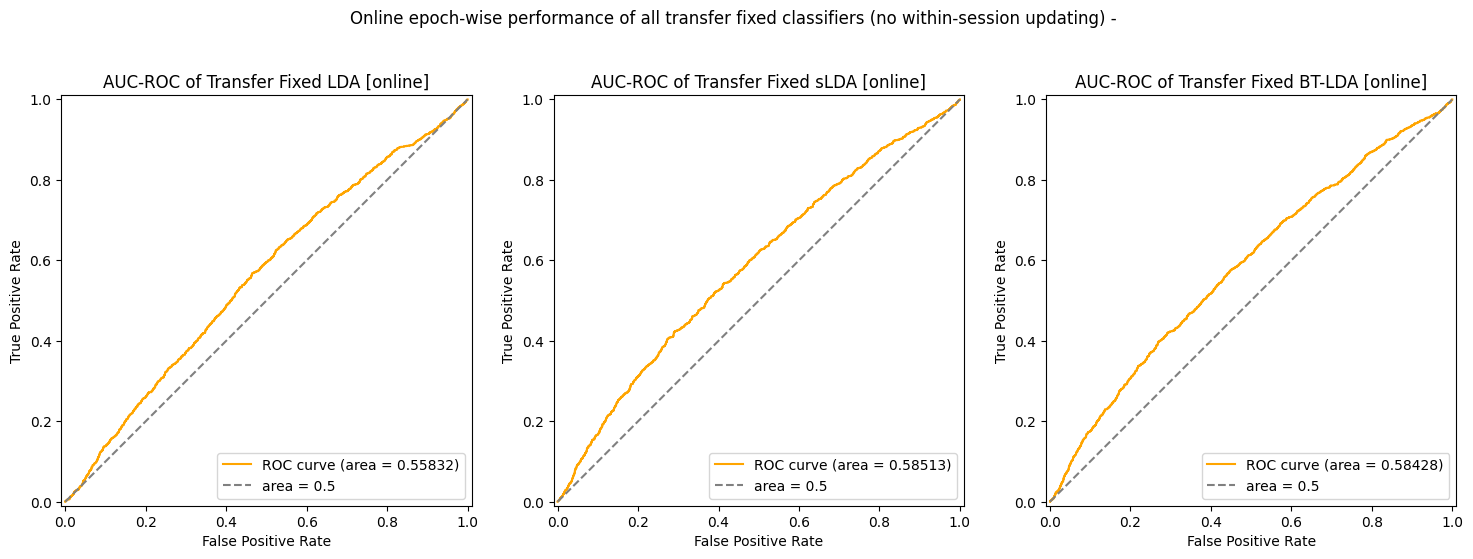

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.41667
Accuracy SLDA: 0.51190
Accuracy BT-LDA: 0.48810


Timer unit: 1e-07 s

Total time: 94.4721 s
File: c:\Users\Soz\OneDrive - Radboud Universiteit\Bureaublad\BSc_Thesis\Code\BSc_Thesis_Project\ERP_analysis_code\patient_pipeline\utils\online_simulation.py
Function: online_simulation at line 65

Line #      Hits         Time  Per Hit   % Time  Line Contents
    65                                           def online_simulation(raw_calibration_data, online_data, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), log_process=None, title_text = ""):
    66                                               """
    67                                               Online simulation of transfer fixed LDA, sLDA, and BT-LDA (with no within-session updating)
    68                                           
    69                                               All three classifiers are trained on the calibration trials. Then, for the online trials in the online simulation, they will predict the label of every played word (epoch) within a trial and decode

In [4]:
ival_bounds = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

data_s1 = load_session_chached("B:/anonymized_data/P01a/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
data_s2 = load_session_chached("B:/anonymized_data/P01a/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)
data_train = merge_sessions(data_s1, data_s2)
data_online = load_session_chached("B:/anonymized_data/P01a/P1_S3/anonymized")

%lprun -f online_simulation online_simulation(data_train, data_online, ival_bounds, log_process="test_ivals_50ms")

## Real online simulation

Procedure
1. Load data
2. Train a classifier on calibration data and evaluate the offline performance
3. Test static classifier in an online simulation of session 3
4. Test adaptive sliding window 

### Experiment: train clf only on session 1+2, simulate online sessions 3-17

#### Experiment 2

#### Experiment 3: growing window per session (updating w/o removing data)

##### function

In [18]:
import logging
import math
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from toeplitzlda.classification import ToeplitzLDA
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime
from utils.preprocessing import _have_same_preprocessing, get_n_epochs, get_iteration_structure
from datetime import datetime


def start_logging(log_file_name):
    # this was needed in order to create a log file
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        filename=log_file_name,
        encoding="utf-8",
        filemode="w", # 'a' to not overwrite current log, 'w' to overwrite. This setting can be changed later
        level=logging.DEBUG,
        format='%(message)s')

def close_logging():
    # close and remove all handlers
    logger = logging.getLogger()
    for handler in logger.handlers[:]:
        handler.close()
        logger.removeHandler(handler)

def log_filenames(filenames):
    if filenames is None:
        log_text = "No filenames were given when the training data was passed"
    else:
        log_text = f"data filenames: {filenames}"
    return log_text        

def log_preprocessing(preprocessing_dictionary):
    if preprocessing_dictionary is None:
        text = "No preprocessing configurations were passed..."
    else:    
        text = "------------------------- Preprocessing configurations -------------------------"
        keys = preprocessing_dictionary.keys()
        for key in keys:
            value = preprocessing_dictionary.get(key)
            text += f"\n{key}: {value}"
        #text += "\n--------------------------------------------------------------------------------"
    return text

def log_feature_extraction(ival_bounds, X_shape=None, y_shape=None):
    if ival_bounds is None:
        text = "No time intervals were passed..."
    else:    
        text = "------------------------- Feature extraction -------------------------"
        text += f"\ntime_interval_boundaries: {ival_bounds}"
        text += f"\ndata_is_channel_prime: {True}" # this is hard coded
        if X_shape and y_shape is not None:
            text += f"\nX.shape (epochs, features): {X_shape}"
            text += f"\ny.shape (epochs,): {y_shape}"
        text += "\n----------------------------------------------------------------------"
    return text




def online_adaptation_simulation_gw(raw_calibration_trials, online_trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), log_process=None, preprocessing_calibration = None, filenames_calibration = None, preprocessing_online = None, filenames_online = None):
    """
    Online simulation withs sliding window adaptation. For every epoch, add that epoch to the training set and remove the oldest epoch from the training set. Update the classifiers only after a trial has finished.

    See online_simulation() for documentation.
    """

    if log_process is not None:
        start_logging(log_process)
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        logging.info(f"New log file - {timestamp}")
        logging.info("================================ Calibration ================================")
        logging.info(f"Calibration {log_filenames(filenames_calibration)}")
        logging.info(log_preprocessing(preprocessing_calibration))

    # Feature extraction
    clf_ival_boundaries = ival_bounds
    X_train, y_train = epoch_vectorizer_channelprime(raw_calibration_trials=raw_calibration_trials, ival_bounds=ival_bounds)

    ### Calibration -----------------------------------------------------------------------

    ## LDA
    ldaclf = make_pipeline(LDA(),)
    ldaclf.fit(X_train,y_train)
    ## Shrinkage LDA
    slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    slda.fit(X_train,y_train)
    ## BT-LDA
    nch = (raw_calibration_trials[0][0]).info["nchan"]
    btlda = make_pipeline(ToeplitzLDA(n_channels=nch),)
    btlda.fit(X_train,y_train)


    if log_process:
        logging.info(log_feature_extraction(ival_bounds, X_train.shape, y_train.shape))
        logging.info(f"n_calibration_trials: {len(raw_calibration_trials)}")
        logging.info(f"n_calibration_epochs: {get_n_epochs(raw_calibration_trials)}")
        logging.info(f"with the per-run iteration structure:\n{get_iteration_structure(raw_calibration_trials)}")
        logging.info("Trained all three classifiers on the calibration data.")
        logging.info("================================ Online ================================")
        logging.info(f"Online {log_filenames(filenames_online)}")
        if _have_same_preprocessing(preprocessing_calibration, preprocessing_online):
            logging.info("Same preprocessing configurations as for the calibration data")
        else:
            logging.info(log_preprocessing(preprocessing_online))
        logging.info(log_feature_extraction(ival_bounds))
        logging.info(f"n_online_trials: {len(online_trials)}")
        logging.info(f"n_online_epochs {get_n_epochs(online_trials)}")
        logging.info(f"with the per-run iteration structure:\n{get_iteration_structure(online_trials)}")
        logging.info("Online simulation starts")
        logging.info(f"Number of online trials: {len(online_trials)}, which is {len(online_trials)/6} runs")


    ### Online simulation ------------------------------------------------------------------

    # Extract relevant data, labels and the played words
    online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
    online_labels = [(1 if event > 107 else 0) for trial in online_trials for iteration in trial for event in iteration.events[:,2]]            
    online_labels = np.array(online_labels) 
    online_words = [(iteration.events[:,2]%10) for trial in online_trials for iteration in trial]
    online_words = np.array(online_words) 

    # compute distances to the decision boundary per epoch
    signed_distances_lda = np.zeros(len(online_labels))
    signed_distances_slda = np.zeros(len(online_labels))
    signed_distances_btlda = np.zeros(len(online_labels))

    epoch_count = 0 
    played_word_count = 0

    # word decision after a trial
    trial_predictions_lda = np.zeros(online_trial_targets.shape)
    trial_predictions_slda = np.zeros(online_trial_targets.shape)
    trial_predictions_btlda = np.zeros(online_trial_targets.shape)

    for t, trial in enumerate(online_trials):
        print("trial {}/{}".format(t, len(online_trials)))
        if log_process:
            run_nr = math.trunc(t/6)+1
            logging.info(f"------------------ Run {run_nr} Trial {t%6+1}  (total trials: {t+1}/{len(online_trials)}) ------------------")
            logging.info("{epoch} | {word_id} | {LDA} \t\t\t\t| {SLDA} \t\t\t\t| {BTLDA} ")

        stim_distances_lda = np.zeros((len(trial),6))
        stim_distances_slda = np.zeros((len(trial),6))
        stim_distances_btlda = np.zeros((len(trial),6))

        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):

                # Obtain x (of a single epoch)
                x1 = get_jumping_means(iteration[s],clf_ival_boundaries)
                x2 = x1.transpose(0,2,1)
                x3 = x2.flatten()
                x4 = x3.reshape(1,-1)
                new_x = x4

                # Compute signed distance of stimulus to decision boundary
                s1 = (ldaclf.decision_function(new_x))[0]
                signed_distances_lda[epoch_count] = s1 
                s2 = (slda.decision_function(new_x))[0]
                signed_distances_slda[epoch_count] = s2
                s3 = btlda.decision_function(new_x).item()
                signed_distances_btlda[epoch_count] = s3 
                
                if log_process:
                    marker = iteration[s].events[:,2]
                    logging.info(f"{epoch_count} \t| {marker} \t| {s1} \t| {s2} \t| {s3}")

                # for word decision
                word_id = online_words[played_word_count,s] - 1 
                stim_distances_lda[i,word_id] = s1 
                stim_distances_slda[i,word_id] = s2
                stim_distances_btlda[i,word_id] = s3 

                ### adaptation (sliding window)
                x = new_x
                y = online_labels[epoch_count]
                # update X_train and y_train data
                X_train = np.append(X_train,x, axis=0)
                # X_train = X_train[1:] DO NOT remove old data
                y_train = np.append(y_train,y)
                # y_train = y_train[1:] DO NOT remove old data
                # note that we did not update our classifier (yet)
                epoch_count+=1 

            
            played_word_count += 1

        # End of trial
        means_lda = np.mean(stim_distances_lda, axis=0) # get the mean distance for each word in the trial
        means_slda = np.mean(stim_distances_slda, axis=0) # get the mean distance for each word in the trial
        means_btlda = np.mean(stim_distances_btlda, axis=0) # get the mean distance for each word in the trial

        best_guess_lda = np.argmax(means_lda) # predict the word
        best_guess_slda = np.argmax(means_slda) # predict the word
        best_guess_btlda = np.argmax(means_btlda) # predict the word

        # For p-values
        # best_distances_lda = stim_distances_lda[:, best_guess_lda].flatten()
        # best_distances_slda = stim_distances_slda[:, best_guess_slda].flatten()
        # best_distances_btlda = stim_distances_btlda[:, best_guess_btlda].flatten()
        #
        # not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
        # t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)
        #
        #print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p)) 

        trial_predictions_lda[t] = best_guess_lda + 1
        trial_predictions_slda[t] = best_guess_slda + 1
        trial_predictions_btlda[t] = best_guess_btlda + 1

        ### Adaptation: update our classifier after a trial has finished

        ## LDA
        ldaclf = make_pipeline(LDA(),)
        ldaclf.fit(X_train,y_train)
        ## Shrinkage LDA
        slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
        slda.fit(X_train,y_train)
        ## BT-LDA
        btlda = make_pipeline(ToeplitzLDA(n_channels=nch),)
        btlda.fit(X_train,y_train)

        if log_process:
            logging.info("------------------ End of trial ------------------")
            logging.info("{real_word} | {LDA_prediction} \t| {SLDA_prediction} \t| {BTLDA_prediction} ")
            logging.info("{} \t\t\t| {} \t\t\t\t| {} \t\t\t\t\t| {} ".format(online_trial_targets[t],best_guess_lda+1,best_guess_slda+1,best_guess_btlda+1))
            logging.info("Updated all three classifiers, this trial is now included in the training set")

    print("------------------ Epoch-wise performance ------------------")

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18,6)) # 1 row, 3 columns 

    fpr_lda, tpr_lda, thresholds = metrics.roc_curve(online_labels,signed_distances_lda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr_lda, tpr = tpr_lda)
    auc_fig.plot(ax=axes[0],color='orange',label="AUC")
    axes[0].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
    axes[0].legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
    axes[0].set_title("AUC-ROC of adaptive LDA [online] [sw]")

    fpr_slda, tpr_slda, thresholds = metrics.roc_curve(online_labels,signed_distances_slda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr_slda, tpr = tpr_slda)
    auc_fig.plot(ax=axes[1],color='orange',label="AUC")
    axes[1].plot([0, 1],[0,1], '--', color="gray", label="area = 0.5")
    axes[1].legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
    axes[1].set_title("AUC-ROC of adaptive sLDA [online] [sw]")

    fpr_btlda, tpr_btlda, thresholds = metrics.roc_curve(online_labels,signed_distances_btlda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr_btlda, tpr = tpr_btlda)
    auc_fig.plot(ax=axes[2],color='orange',label="AUC")
    axes[2].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
    axes[2].legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
    axes[2].set_title("AUC-ROC of adaptive BT-LDA [online] [sw]")
    
    plt.suptitle(f"Online epoch-wise performance of all classifiers using sliding window updating")
    plt.show()

    if log_process:
        logging.info("End of online simulation")
        logging.info("------------------ Epoch-wise performance ------------------")
        logging.info(f"AUC-ROC LDA: {metrics.auc(fpr_lda, tpr_lda):.5f}")
        logging.info(f"AUC-ROC SLDA: {metrics.auc(fpr_slda, tpr_slda):.5f}")
        logging.info(f"AUC-ROC BT-LDA: {metrics.auc(fpr_btlda, tpr_btlda):0.5f}")

    print("------------------ Word prediction performance (per trial) ------------------")
    print(f"Accuracy LDA: {np.mean(trial_predictions_lda == online_trial_targets):.5f}")
    print(f"Accuracy SLDA: {np.mean(trial_predictions_slda == online_trial_targets):.5f}")
    print(f"Accuracy BT-LDA: {np.mean(trial_predictions_btlda == online_trial_targets):0.5f}")

    # For p-values
    # plot_distribution_comparison(not_best_distances, best_distances) (see assignment 07)

    if log_process:
        logging.info("------------------ Word prediction performance (per trial) ------------------")
        logging.info(f"Accuracy LDA: {np.mean(trial_predictions_lda == online_trial_targets):.5f} ({np.sum(trial_predictions_lda == online_trial_targets)} correct out of {len(online_trial_targets)})")
        logging.info(f"Accuracy SLDA: {np.mean(trial_predictions_slda == online_trial_targets):.5f} ({np.sum(trial_predictions_slda == online_trial_targets)} correct out of {len(online_trial_targets)})")
        logging.info(f"Accuracy BT-LDA: {np.mean(trial_predictions_btlda == online_trial_targets):.5f} ({np.sum(trial_predictions_btlda == online_trial_targets)} correct out of {len(online_trial_targets)})")

        close_logging()
        
    performances = {
        "epoch-wise": {
            "lda": metrics.auc(fpr_lda, tpr_lda),
            "slda": metrics.auc(fpr_slda, tpr_slda),
            "btlda": metrics.auc(fpr_btlda, tpr_btlda),
        },
        "trial-wise": {
            "lda": np.mean(trial_predictions_lda == online_trial_targets),
            "slda": np.mean(trial_predictions_slda == online_trial_targets),
            "btlda": np.mean(trial_predictions_btlda == online_trial_targets),
        },
        "trial_predictions":{
            "lda": trial_predictions_lda,
            "slda": trial_predictions_slda,
            "btlda": trial_predictions_btlda,
            "true": online_trial_targets
        }
    }
    
    return performances

##### experiment

Loading file:  data_p1_P1_S1_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  data_p1_P1_S2_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
All calibration trials:  30
That is 2700 epochs

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84

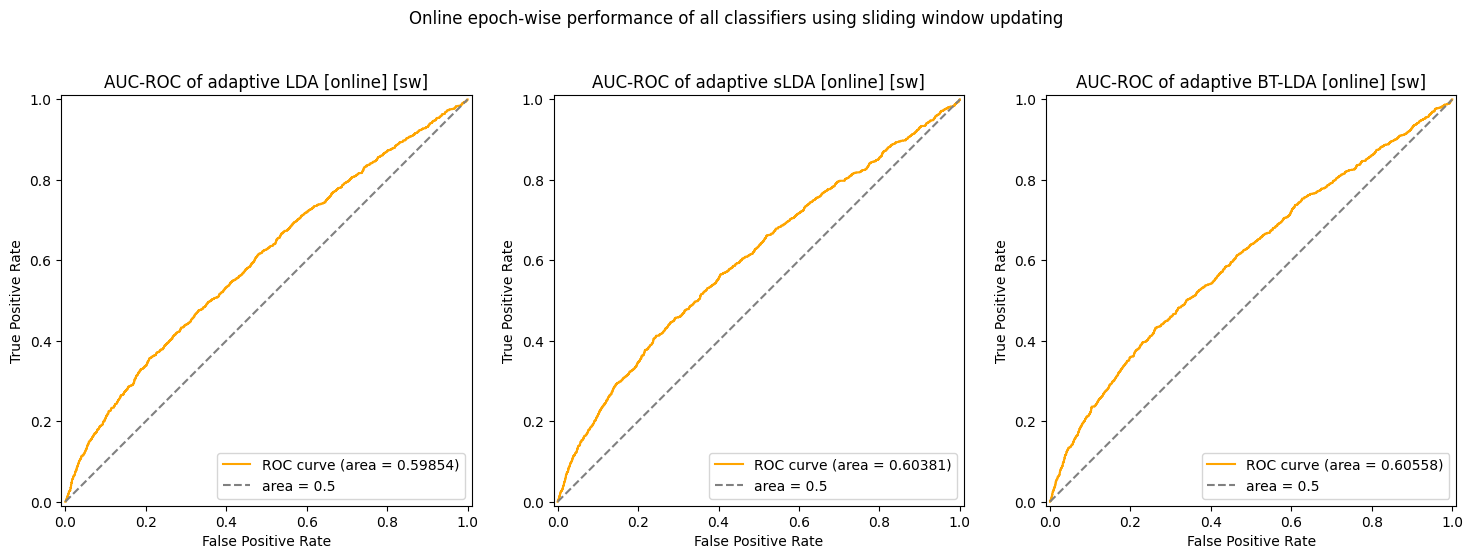

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.53571
Accuracy SLDA: 0.55952
Accuracy BT-LDA: 0.58333
Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
trial 48/102
trial 49/102
trial 50/102
trial 51/102


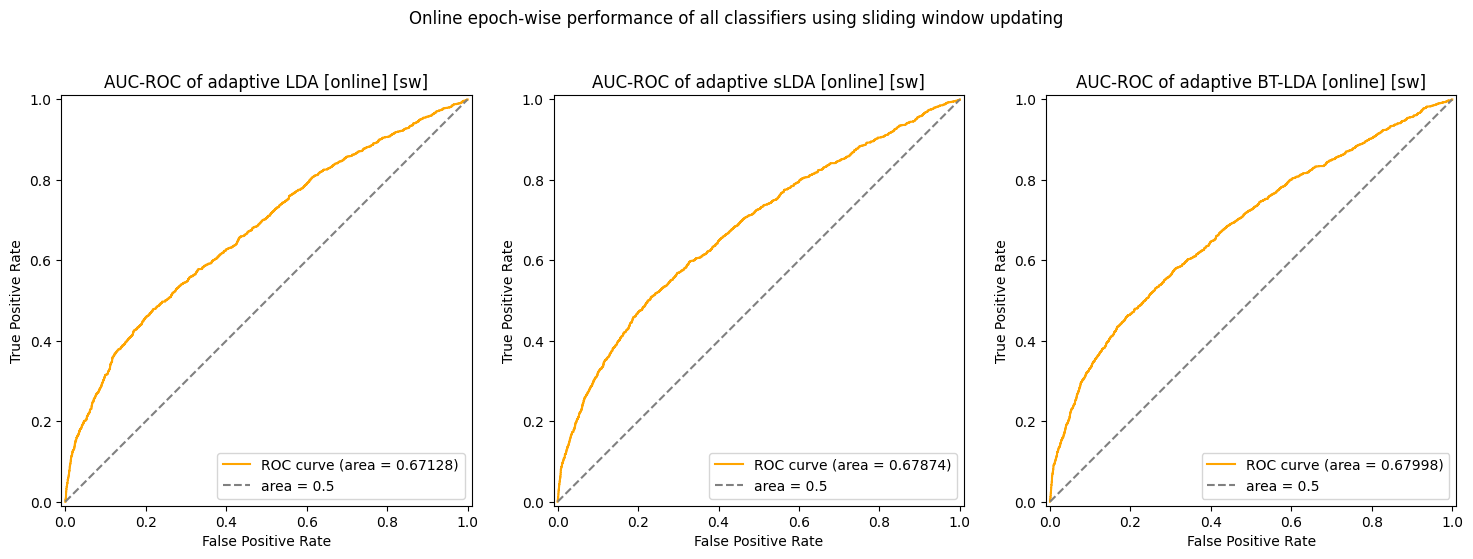

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.70588
Accuracy SLDA: 0.65686
Accuracy BT-LDA: 0.65686
Loading file:  data_p1_P1_S5_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S5_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S5_anonymized.pkl
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
tria

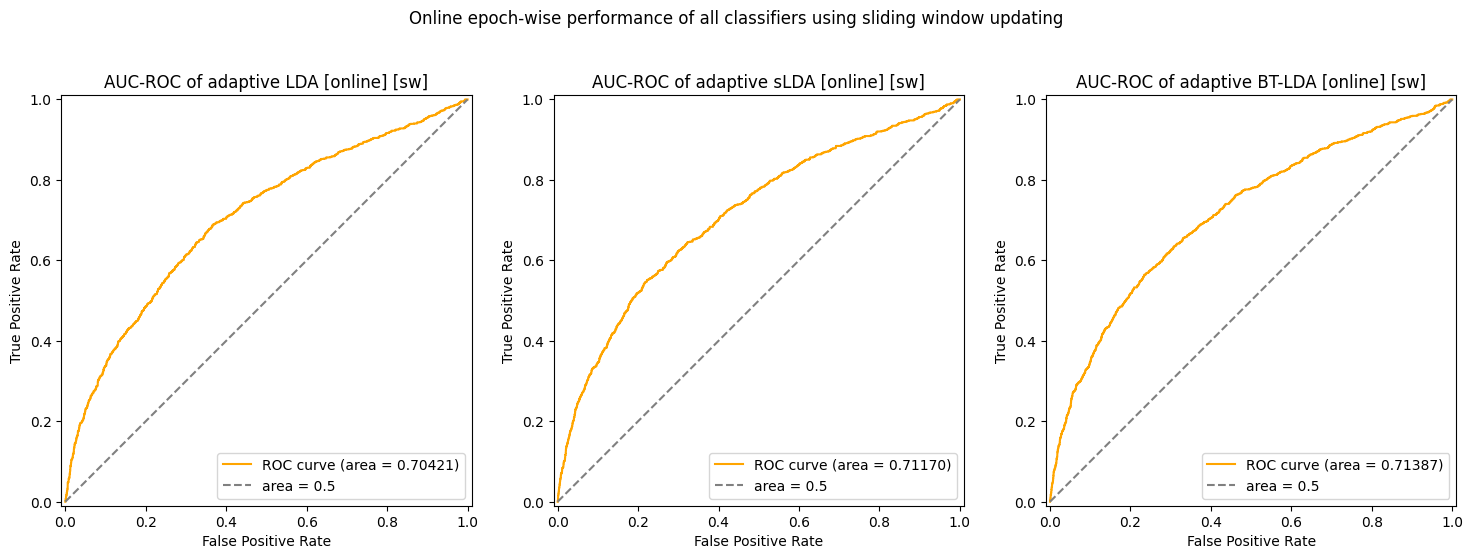

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.72619
Accuracy SLDA: 0.75000
Accuracy BT-LDA: 0.76190
Loading file:  data_p1_P1_S6_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S6_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S6_anonymized.pkl
trial 0/108
trial 1/108
trial 2/108
trial 3/108
trial 4/108
trial 5/108
trial 6/108
trial 7/108
trial 8/108
trial 9/108
trial 10/108
trial 11/108
trial 12/108
trial 13/108
trial 14/108
trial 15/108
trial 16/108
trial 17/108
trial 18/108
trial 19/108
trial 20/108
trial 21/108
trial 22/108
trial 23/108
trial 24/108
trial 25/108
trial 26/108
trial 27/108
trial 28/108
trial 29/108
trial 30/108
trial 31/108
trial 32/108
trial 33/108
trial 34/108
trial 35/108
trial 36/108
trial 37/108
trial 38/108
trial 39/108
trial 40/108
trial 41/108
trial 42/108
trial 43/108
trial 44/108
trial 45/108
trial 46/108
trial 47/108
trial 48/108
trial 49/108
trial 50/108
trial 51/108


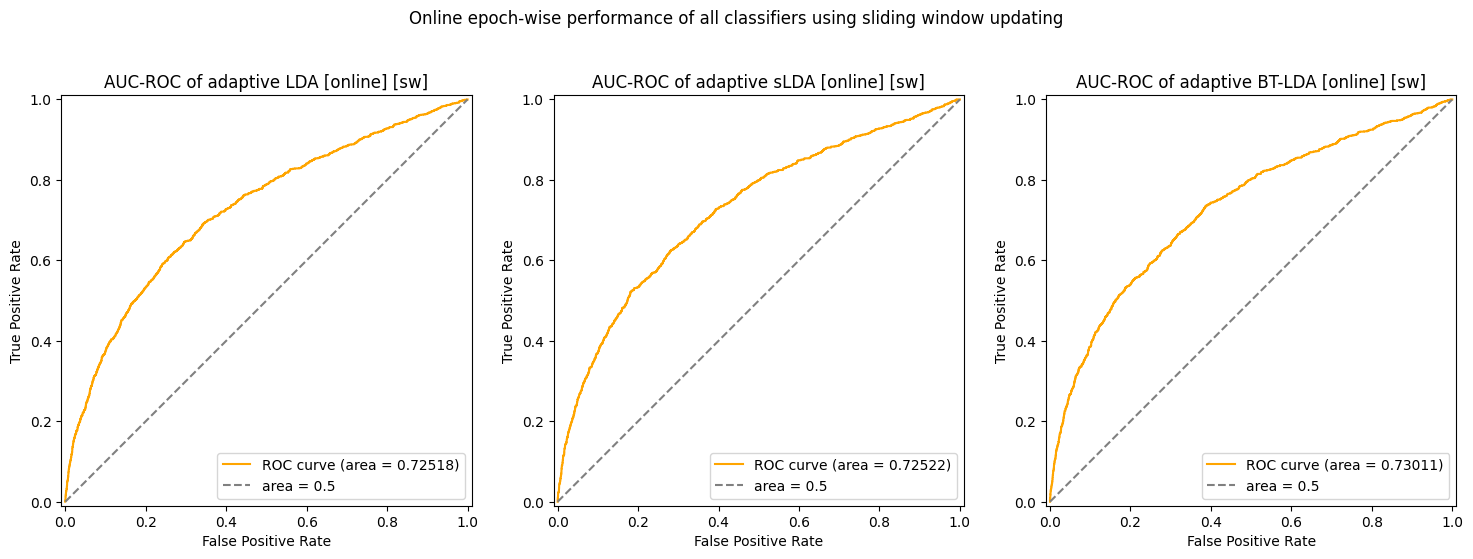

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.75926
Accuracy SLDA: 0.74074
Accuracy BT-LDA: 0.72222
Loading file:  data_p1_P1_S7_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S7_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S7_anonymized.pkl
trial 0/108
trial 1/108
trial 2/108
trial 3/108
trial 4/108
trial 5/108
trial 6/108
trial 7/108
trial 8/108
trial 9/108
trial 10/108
trial 11/108
trial 12/108
trial 13/108
trial 14/108
trial 15/108
trial 16/108
trial 17/108
trial 18/108
trial 19/108
trial 20/108
trial 21/108
trial 22/108
trial 23/108
trial 24/108
trial 25/108
trial 26/108
trial 27/108
trial 28/108
trial 29/108
trial 30/108
trial 31/108
trial 32/108
trial 33/108
trial 34/108
trial 35/108
trial 36/108
trial 37/108
trial 38/108
trial 39/108
trial 40/108
trial 41/108
trial 42/108
trial 43/108
trial 44/108
trial 45/108
trial 46/108
trial 47/108
trial 48/108
trial 49/108
trial 50/108
trial 51/108


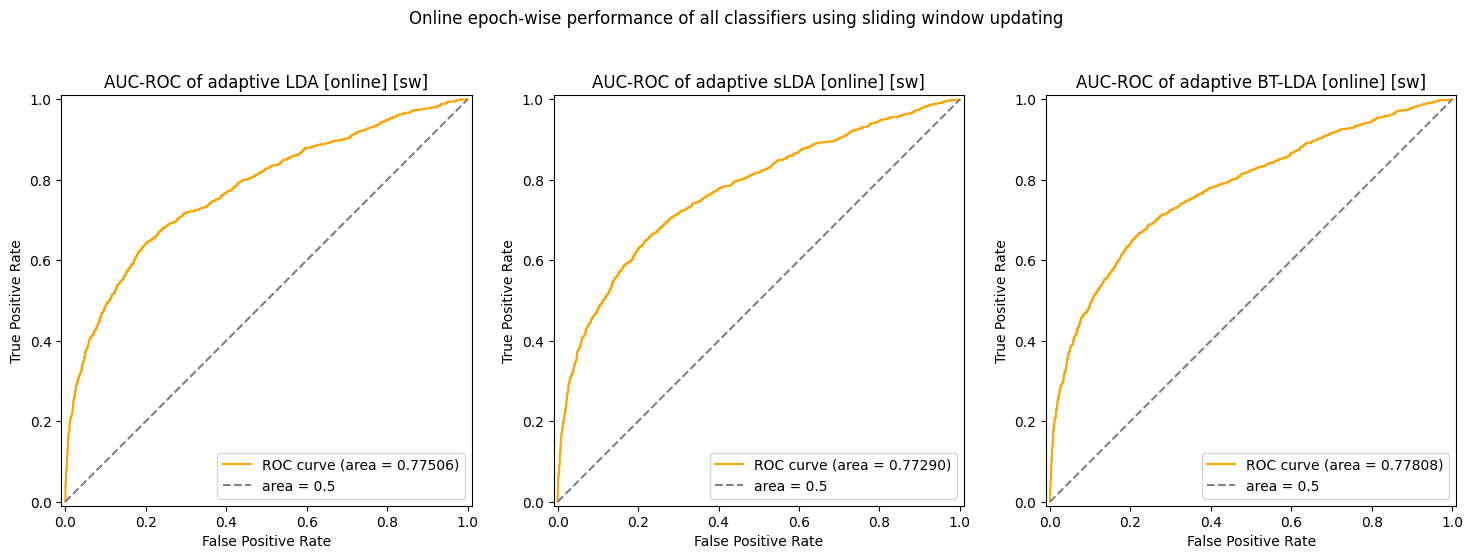

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.85185
Accuracy SLDA: 0.84259
Accuracy BT-LDA: 0.84259
Loading file:  data_p1_P1_S8_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S8_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S8_anonymized.pkl
trial 0/108
trial 1/108
trial 2/108
trial 3/108
trial 4/108
trial 5/108
trial 6/108
trial 7/108
trial 8/108
trial 9/108
trial 10/108
trial 11/108
trial 12/108
trial 13/108
trial 14/108
trial 15/108
trial 16/108
trial 17/108
trial 18/108
trial 19/108
trial 20/108
trial 21/108
trial 22/108
trial 23/108
trial 24/108
trial 25/108
trial 26/108
trial 27/108
trial 28/108
trial 29/108
trial 30/108
trial 31/108
trial 32/108
trial 33/108
trial 34/108
trial 35/108
trial 36/108
trial 37/108
trial 38/108
trial 39/108
trial 40/108
trial 41/108
trial 42/108
trial 43/108
trial 44/108
trial 45/108
trial 46/108
trial 47/108
trial 48/108
trial 49/108
trial 50/108
trial 51/108


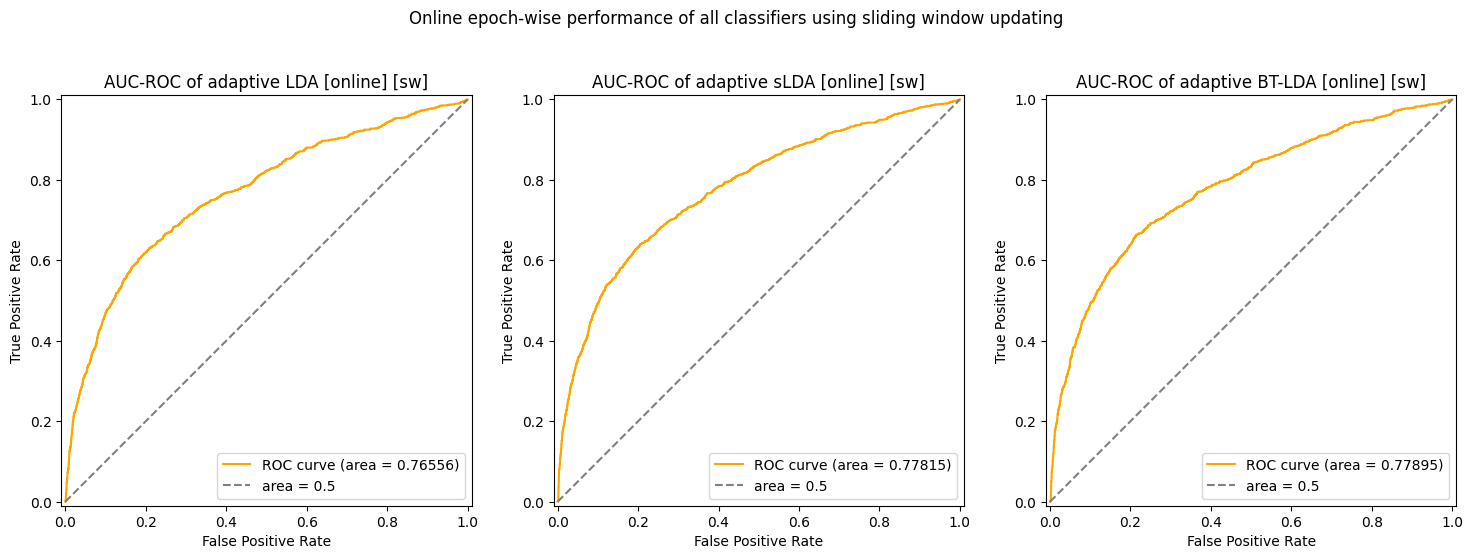

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.83333
Accuracy SLDA: 0.87037
Accuracy BT-LDA: 0.87963
Loading file:  data_p1_P1_S9_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S9_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S9_anonymized.pkl
trial 0/120
trial 1/120
trial 2/120
trial 3/120
trial 4/120
trial 5/120
trial 6/120
trial 7/120
trial 8/120
trial 9/120
trial 10/120
trial 11/120
trial 12/120
trial 13/120
trial 14/120
trial 15/120
trial 16/120
trial 17/120
trial 18/120
trial 19/120
trial 20/120
trial 21/120
trial 22/120
trial 23/120
trial 24/120
trial 25/120
trial 26/120
trial 27/120
trial 28/120
trial 29/120
trial 30/120
trial 31/120
trial 32/120
trial 33/120
trial 34/120
trial 35/120
trial 36/120
trial 37/120
trial 38/120
trial 39/120
trial 40/120
trial 41/120
trial 42/120
trial 43/120
trial 44/120
trial 45/120
trial 46/120
trial 47/120
trial 48/120
trial 49/120
trial 50/120
trial 51/120


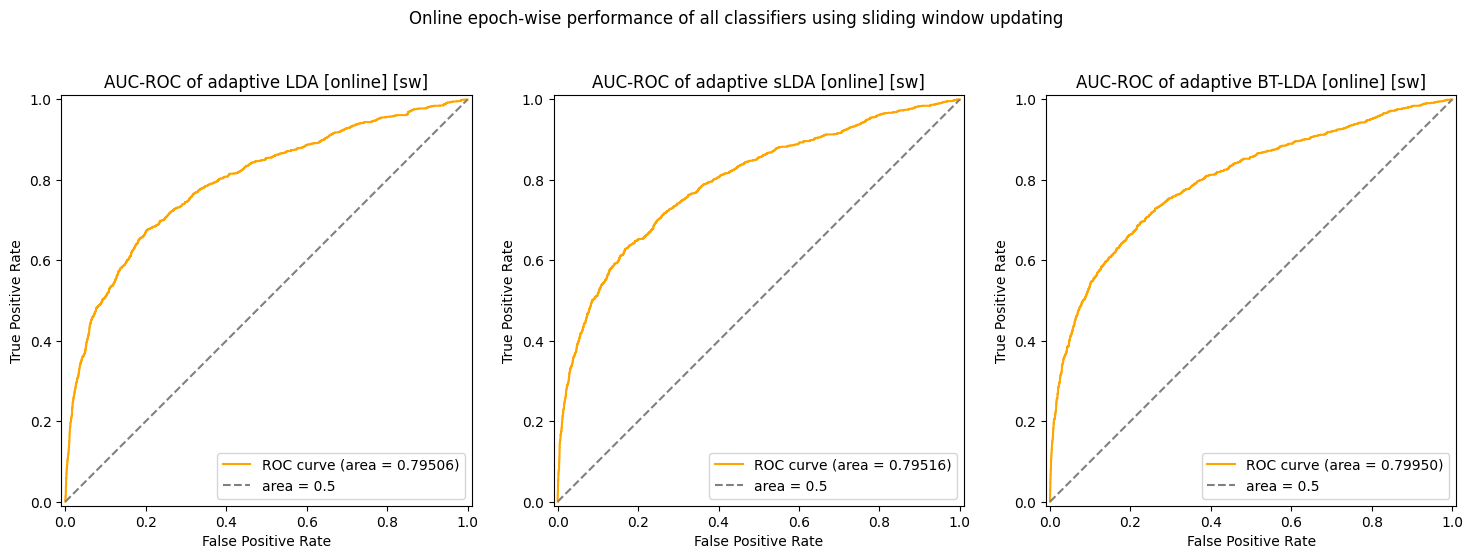

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.90000
Accuracy SLDA: 0.90000
Accuracy BT-LDA: 0.89167
Loading file:  data_p1_P1_S10_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S10_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S10_anonymized.pkl
trial 0/126
trial 1/126
trial 2/126
trial 3/126
trial 4/126
trial 5/126
trial 6/126
trial 7/126
trial 8/126
trial 9/126
trial 10/126
trial 11/126
trial 12/126
trial 13/126
trial 14/126
trial 15/126
trial 16/126
trial 17/126
trial 18/126
trial 19/126
trial 20/126
trial 21/126
trial 22/126
trial 23/126
trial 24/126
trial 25/126
trial 26/126
trial 27/126
trial 28/126
trial 29/126
trial 30/126
trial 31/126
trial 32/126
trial 33/126
trial 34/126
trial 35/126
trial 36/126
trial 37/126
trial 38/126
trial 39/126
trial 40/126
trial 41/126
trial 42/126
trial 43/126
trial 44/126
trial 45/126
trial 46/126
trial 47/126
trial 48/126
trial 49/126
trial 50/126
trial 51/1

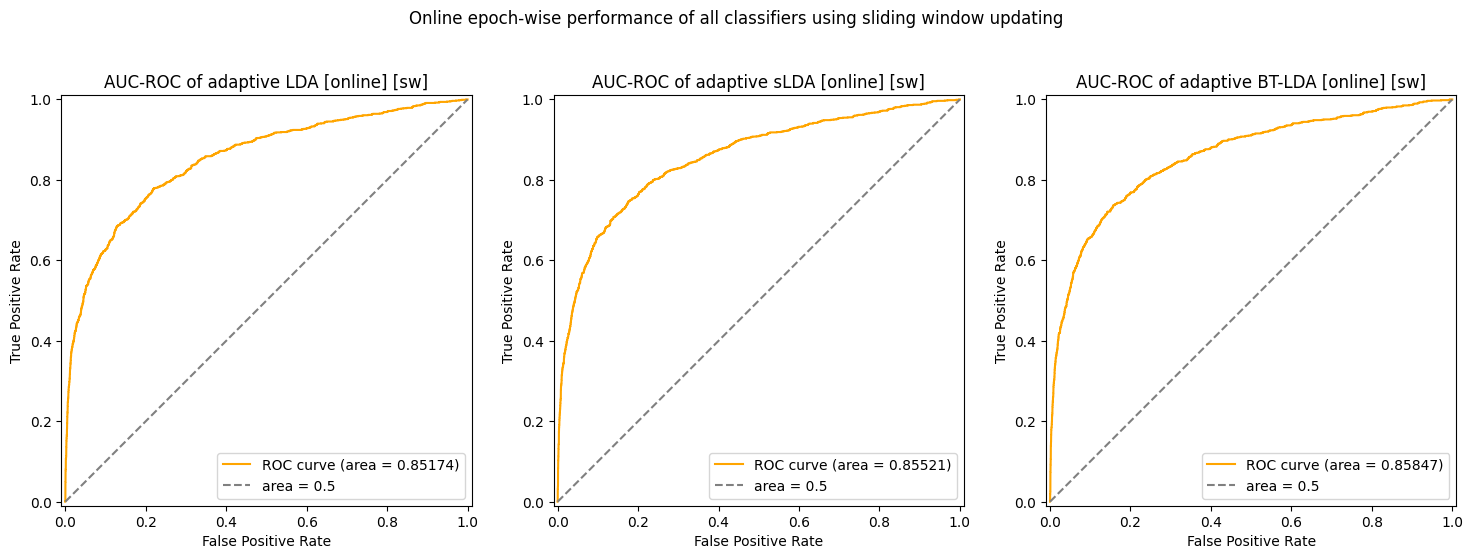

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.94444
Accuracy SLDA: 0.93651
Accuracy BT-LDA: 0.94444
Loading file:  data_p1_P1_S11_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S11_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S11_anonymized.pkl
trial 0/138
trial 1/138
trial 2/138
trial 3/138
trial 4/138
trial 5/138
trial 6/138
trial 7/138
trial 8/138
trial 9/138
trial 10/138
trial 11/138
trial 12/138
trial 13/138
trial 14/138
trial 15/138
trial 16/138
trial 17/138
trial 18/138
trial 19/138
trial 20/138
trial 21/138
trial 22/138
trial 23/138
trial 24/138
trial 25/138
trial 26/138
trial 27/138
trial 28/138
trial 29/138
trial 30/138
trial 31/138
trial 32/138
trial 33/138
trial 34/138
trial 35/138
trial 36/138
trial 37/138
trial 38/138
trial 39/138
trial 40/138
trial 41/138
trial 42/138
trial 43/138
trial 44/138
trial 45/138
trial 46/138
trial 47/138
trial 48/138
trial 49/138
trial 50/138
trial 51/1

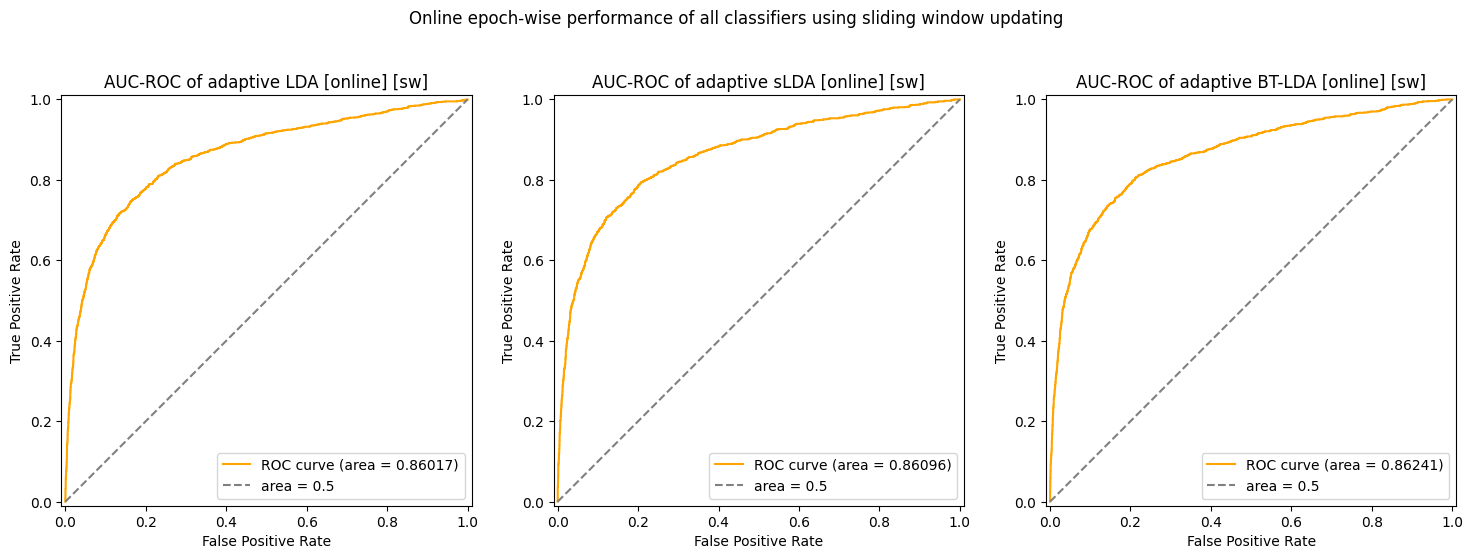

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.96377
Accuracy SLDA: 0.96377
Accuracy BT-LDA: 0.96377
Loading file:  data_p1_P1_S12_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S12_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S12_anonymized.pkl
trial 0/114
trial 1/114
trial 2/114
trial 3/114
trial 4/114
trial 5/114
trial 6/114
trial 7/114
trial 8/114
trial 9/114
trial 10/114
trial 11/114
trial 12/114
trial 13/114
trial 14/114
trial 15/114
trial 16/114
trial 17/114
trial 18/114
trial 19/114
trial 20/114
trial 21/114
trial 22/114
trial 23/114
trial 24/114
trial 25/114
trial 26/114
trial 27/114
trial 28/114
trial 29/114
trial 30/114
trial 31/114
trial 32/114
trial 33/114
trial 34/114
trial 35/114
trial 36/114
trial 37/114
trial 38/114
trial 39/114
trial 40/114
trial 41/114
trial 42/114
trial 43/114
trial 44/114
trial 45/114
trial 46/114
trial 47/114
trial 48/114
trial 49/114
trial 50/114
trial 51/1

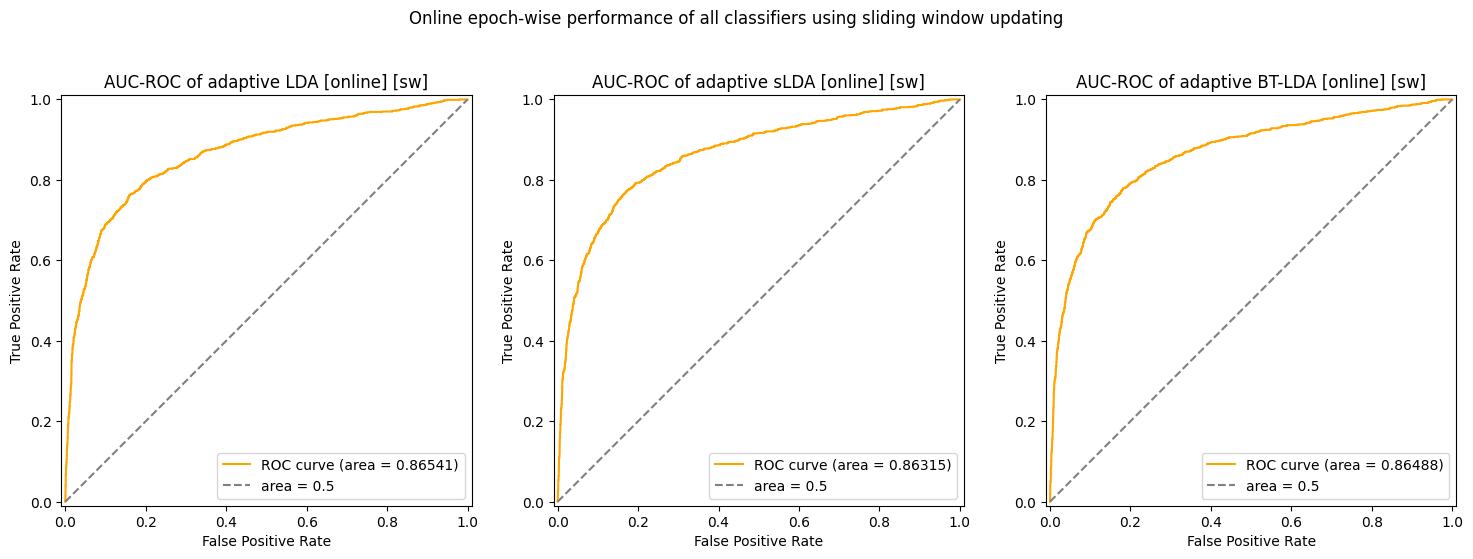

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.93860
Accuracy SLDA: 0.95614
Accuracy BT-LDA: 0.95614
Loading file:  data_p1_P1_S13_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S13_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S13_anonymized.pkl
trial 0/126
trial 1/126
trial 2/126
trial 3/126
trial 4/126
trial 5/126
trial 6/126
trial 7/126
trial 8/126
trial 9/126
trial 10/126
trial 11/126
trial 12/126
trial 13/126
trial 14/126
trial 15/126
trial 16/126
trial 17/126
trial 18/126
trial 19/126
trial 20/126
trial 21/126
trial 22/126
trial 23/126
trial 24/126
trial 25/126
trial 26/126
trial 27/126
trial 28/126
trial 29/126
trial 30/126
trial 31/126
trial 32/126
trial 33/126
trial 34/126
trial 35/126
trial 36/126
trial 37/126
trial 38/126
trial 39/126
trial 40/126
trial 41/126
trial 42/126
trial 43/126
trial 44/126
trial 45/126
trial 46/126
trial 47/126
trial 48/126
trial 49/126
trial 50/126
trial 51/1

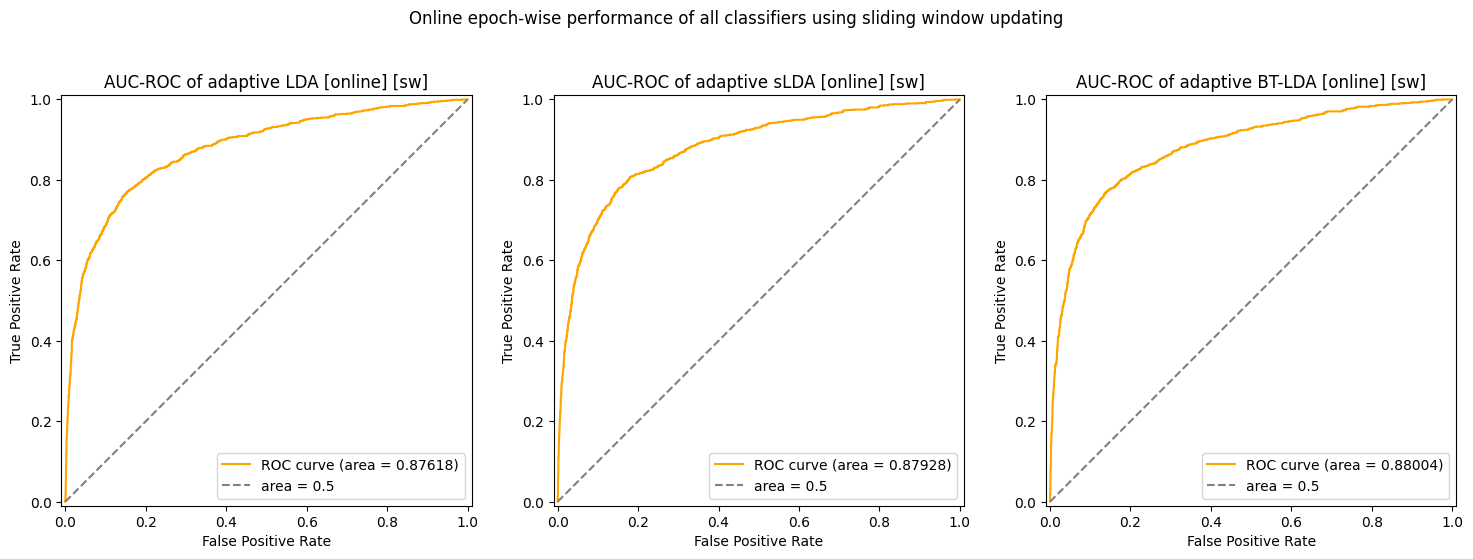

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.94444
Accuracy SLDA: 0.94444
Accuracy BT-LDA: 0.95238
Loading file:  data_p1_P1_S14_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S14_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S14_anonymized.pkl
trial 0/162
trial 1/162
trial 2/162
trial 3/162
trial 4/162
trial 5/162
trial 6/162
trial 7/162
trial 8/162
trial 9/162
trial 10/162
trial 11/162
trial 12/162
trial 13/162
trial 14/162
trial 15/162
trial 16/162
trial 17/162
trial 18/162
trial 19/162
trial 20/162
trial 21/162
trial 22/162
trial 23/162
trial 24/162
trial 25/162
trial 26/162
trial 27/162
trial 28/162
trial 29/162
trial 30/162
trial 31/162
trial 32/162
trial 33/162
trial 34/162
trial 35/162
trial 36/162
trial 37/162
trial 38/162
trial 39/162
trial 40/162
trial 41/162
trial 42/162
trial 43/162
trial 44/162
trial 45/162
trial 46/162
trial 47/162
trial 48/162
trial 49/162
trial 50/162
trial 51/1

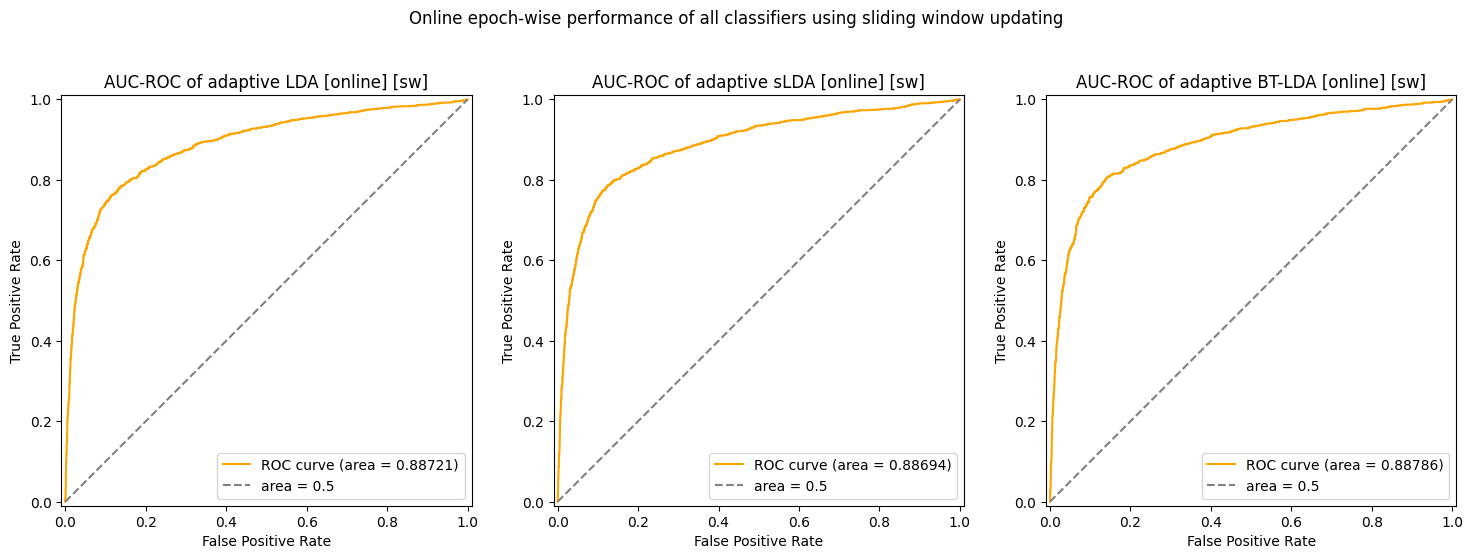

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.98148
Accuracy SLDA: 0.99383
Accuracy BT-LDA: 0.99383
Loading file:  data_p1_P1_S15_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S15_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S15_anonymized.pkl
trial 0/156
trial 1/156
trial 2/156
trial 3/156
trial 4/156
trial 5/156
trial 6/156
trial 7/156
trial 8/156
trial 9/156
trial 10/156
trial 11/156
trial 12/156
trial 13/156
trial 14/156
trial 15/156
trial 16/156
trial 17/156
trial 18/156
trial 19/156
trial 20/156
trial 21/156
trial 22/156
trial 23/156
trial 24/156
trial 25/156
trial 26/156
trial 27/156
trial 28/156
trial 29/156
trial 30/156
trial 31/156
trial 32/156
trial 33/156
trial 34/156
trial 35/156
trial 36/156
trial 37/156
trial 38/156
trial 39/156
trial 40/156
trial 41/156
trial 42/156
trial 43/156
trial 44/156
trial 45/156
trial 46/156
trial 47/156
trial 48/156
trial 49/156
trial 50/156
trial 51/1

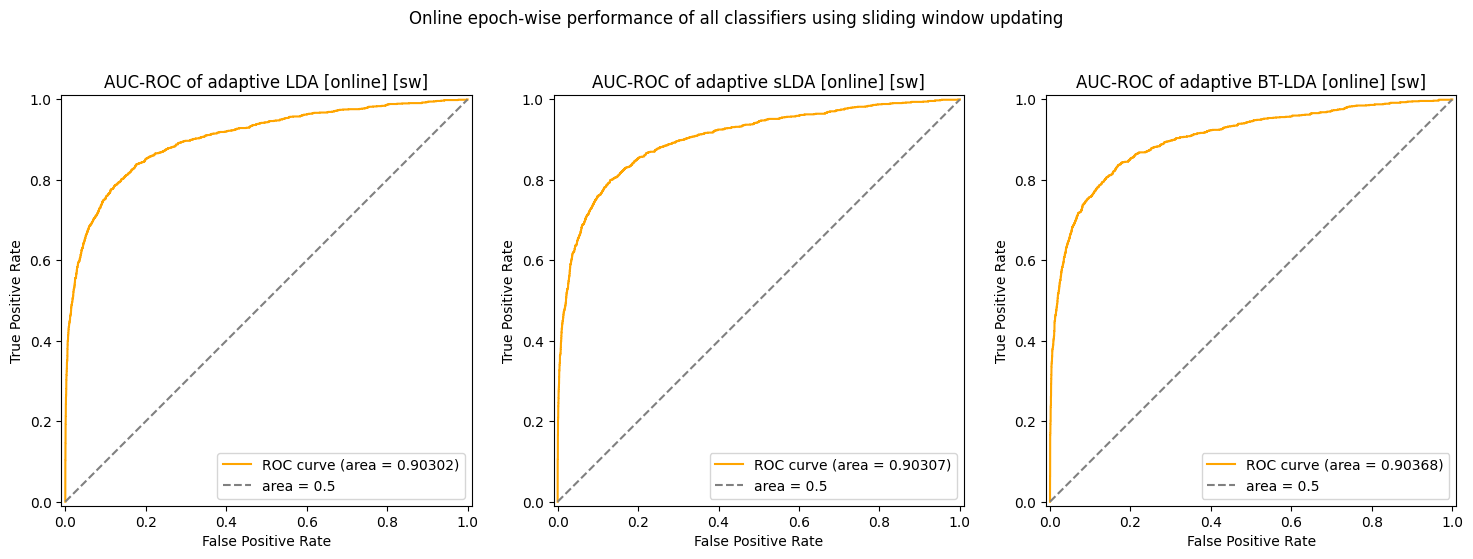

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.99359
Accuracy SLDA: 1.00000
Accuracy BT-LDA: 0.99359
Loading file:  data_p1_P1_S16_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S16_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S16_anonymized.pkl
trial 0/162
trial 1/162
trial 2/162
trial 3/162
trial 4/162
trial 5/162
trial 6/162
trial 7/162
trial 8/162
trial 9/162
trial 10/162
trial 11/162
trial 12/162
trial 13/162
trial 14/162
trial 15/162
trial 16/162
trial 17/162
trial 18/162
trial 19/162
trial 20/162
trial 21/162
trial 22/162
trial 23/162
trial 24/162
trial 25/162
trial 26/162
trial 27/162
trial 28/162
trial 29/162
trial 30/162
trial 31/162
trial 32/162
trial 33/162
trial 34/162
trial 35/162
trial 36/162
trial 37/162
trial 38/162
trial 39/162
trial 40/162
trial 41/162
trial 42/162
trial 43/162
trial 44/162
trial 45/162
trial 46/162
trial 47/162
trial 48/162
trial 49/162
trial 50/162
trial 51/1

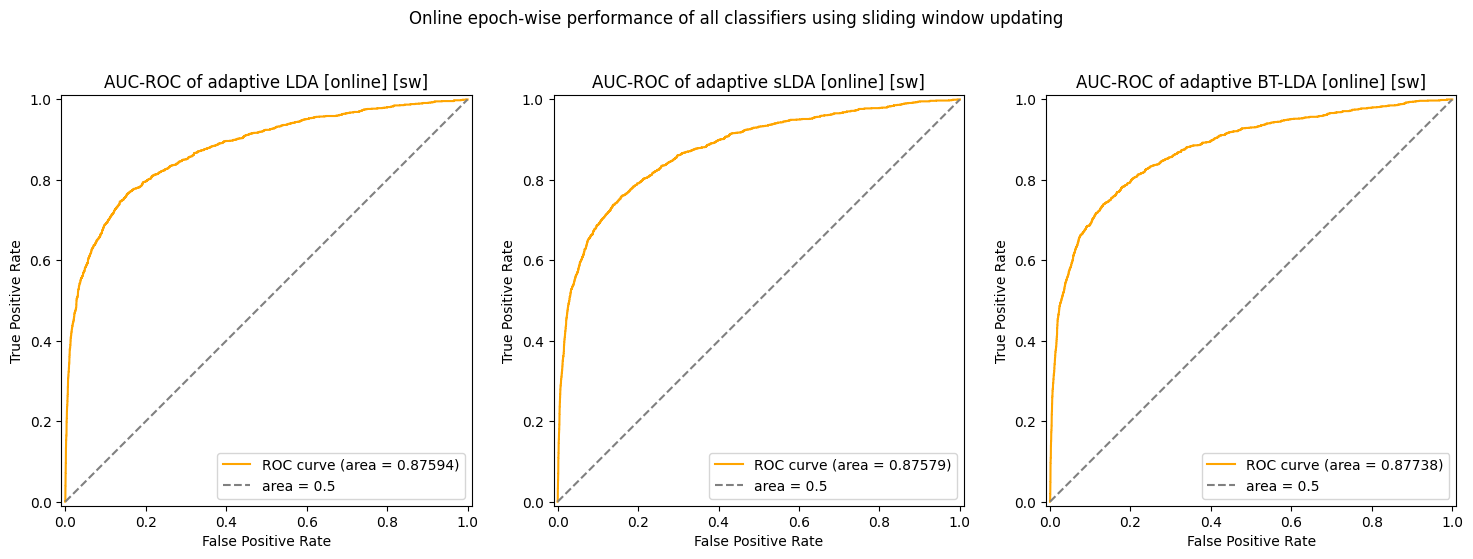

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.97531
Accuracy SLDA: 0.97531
Accuracy BT-LDA: 0.97531
Loading file:  data_p1_P1_S17_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S17_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S17_anonymized.pkl
trial 0/162
trial 1/162
trial 2/162
trial 3/162
trial 4/162
trial 5/162
trial 6/162
trial 7/162
trial 8/162
trial 9/162
trial 10/162
trial 11/162
trial 12/162
trial 13/162
trial 14/162
trial 15/162
trial 16/162
trial 17/162
trial 18/162
trial 19/162
trial 20/162
trial 21/162
trial 22/162
trial 23/162
trial 24/162
trial 25/162
trial 26/162
trial 27/162
trial 28/162
trial 29/162
trial 30/162
trial 31/162
trial 32/162
trial 33/162
trial 34/162
trial 35/162
trial 36/162
trial 37/162
trial 38/162
trial 39/162
trial 40/162
trial 41/162
trial 42/162
trial 43/162
trial 44/162
trial 45/162
trial 46/162
trial 47/162
trial 48/162
trial 49/162
trial 50/162
trial 51/1

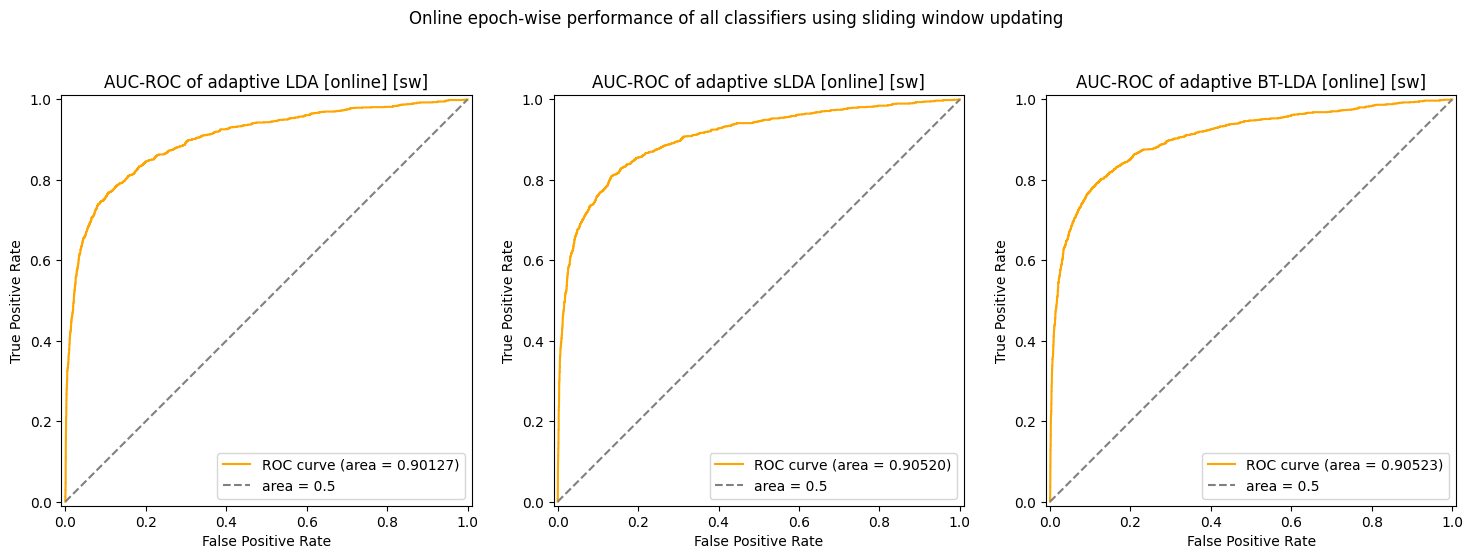

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.98765
Accuracy SLDA: 0.99383
Accuracy BT-LDA: 0.98765


In [20]:
# exp 3
# train clf on previous session, apply growing window strategy on current online test session

exp3_performances = dict()

# Calibration data: sessions 1 and 2 (only runs with conditions 6D and 350)
data_s1 = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
data_s2 = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)
data_train = merge_sessions(data_s1, data_s2)
trials_train = data_train.get('trials')
print("All calibration trials: ",len(trials_train))
print("That is {} epochs\n".format(get_n_epochs(trials_train)))

ppcal = data_train.get('preprocessing')
fncal = data_train.get('filenames')

for i in range(3,18):
    data_test = load_session_chached(f"data_p1/P1_S{i}/anonymized")
    trials_test = data_test.get("trials")

    ppon = data_test.get('preprocessing')
    fnon = data_test.get('filenames')

    # 2. Evaluate offline performance 
    # clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    # compare_auc_single_trial_interval(trials_train, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)
    # compute_auc_with_cv(trials_train, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

    # 3. Online simulation static (trained on session i-1 - applied on session i)
    gw_result = online_adaptation_simulation_gw(trials_train, trials_test, log_process=f"exp3_online_s{i}.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

    exp3_performances.update({f"exp3_p{i}_adaptive_gw":gw_result})


In [30]:
with open('p1_exp3_performances.pkl', 'wb') as f:
    pickle.dump(exp3_performances, f)
# with open('performances_p1_new copy.pkl', 'rb') as f:
#     performances_new = pickle.load(f)    